# Individual tree segmentation from airborne LiDAR — watershed + optimized connection center evolution (ITS_WS_ICCE)

**Paper:** *Individual tree segmentation of airborne and UAV LiDAR point clouds based on the watershed and optimized connection center evolution clustering* — Ecology and Evolution 13(7):e10297, 2023 (DOI: 10.1002/ece3.10297; open-access copy PMC10338759). Li et al.

**Author code:** https://github.com/liyi-rs/ITS_WS_ICCE @ commit `d664a2ca15649aa1e628ea42da8b2c89b44253cf` (no LICENSE file — reuse terms unverified; this notebook is for study).

**Scope:** run the paper's three-step pipeline on the repository's embedded ground-filtered ALS sample `test_data/03_ALS_csf.las` (140 m × 140 m, 157,665 points, ~8 pts/m²):
1. **R / lidR** — pit-free CHM (0.2 m), DTM/TIN normalization, watershed initial segmentation (`lmf(4,2)` treetops).
2. **Python** — `getbandwidth.py` mean-shift bandwidth (author's formula, z scaled by 1/Vr=6).
3. **Octave (author MATLAB core)** — optimized CCE fine segmentation (Vr=1/6, sigSq2=10) + tree metrics (planar position, height, crown diameter).

**Execution status: validated on a fresh Google Colab CPU runtime.** No GPU is used anywhere in this pipeline.

> **AI-assisted environment note:** the authors provided R, Python and MATLAB code, not a Colab notebook. Here the author's numerical core (CCE.m, cce_seg.m, MeanShiftCluster.m, get_treelabel_new.m, get_tree_metric_color.m, randcolor.m, distance2matrix.m) executes **unmodified in GNU Octave**; the R driver needed lidR-4.x API renames, and the MATLAB `table`/`LASread`/`LASwrite` I/O wrapper was replaced by a thin Python laspy hand-off. Every change is documented next to its cell. The executed example was validated; untested behavior is not guaranteed.
>
> **AI支援に関する注記:** 著者は R・Python・MATLAB コードのみを公開しており Colab ノートブックはありません。数値計算コアは Octave で原著のまま実行し、R は lidR 4.x の関数名変更への対応、MATLAB の I/O 部のみ Python laspy に置き換えています。変更点は各セルに明記します。

**JP summary:** 本ノートブックは Li ら (2023) の ALS 個体木分割 ( Watershed 初期分割 + 最適化 CCE 細分割 ) をリポジトリ同梱のサンプル点群 1 枚で実行します。CPU ランタイムで動作します。

## Runtime selection

Select **Runtime → Change runtime type → CPU** (standard). No stage of this method uses GPU; the paper itself reports CPU timings. Run all cells top-to-bottom; expected total ≈ 10–20 min (dominated by package installation), downloads ≈ 5 MB.

**JP:** GPU は不要です。CPU ランタイムを選択し、上から順に実行してください (パッケージ導入を含め合計 10–20 分程度、ダウンロード約 5 MB)。

## 1. Environment setup — Octave and R/lidR

Install GNU Octave (runs the author's MATLAB core) and R's lidR with its watershed dependencies (EBImage, raster, sp, stars, rgl) from the r2u apt repository (CRAN as Ubuntu binaries — fast, dependency-resolved). Python needs `laspy`, `scipy`, `scikit-learn` (Colab has numpy/scipy/sklearn preinstalled). Expected: version numbers printed, no errors.

**JP:** Octave と R/lidR (watershed 依存を含む) を apt 経由で導入します。バージョンが出力されれば成功です。

In [ ]:
import subprocess, time, threading
t0 = time.time()
def sh(cmd, tmo=2400):
    p = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    def beat():
        while p.poll() is None:
            print('.', end='', flush=True); time.sleep(20)
    threading.Thread(target=beat, daemon=True).start()
    for line in p.stdout: print(line, end='', flush=True)
    if p.wait(timeout=tmo) != 0: raise RuntimeError(f'failed: {cmd}')
sh('apt-get update -qq && apt-get install -y -qq gnupg wget ca-certificates > /dev/null 2>&1')
sh("gpg --homedir /tmp --no-default-keyring --keyring /usr/share/keyrings/r2u.gpg --keyserver hkps://keyserver.ubuntu.com:443 --recv-keys A1489FE2AB99A21A 67C2D66C4B1D4339 51716619E084DAB9 2>&1 | tail -1")
sh('printf "Types: deb\\nURIs: https://r2u.stat.illinois.edu/ubuntu\\nSuites: $(lsb_release -cs)\\nComponents: main\\nArchitectures: amd64\\nSigned-By: /usr/share/keyrings/r2u.gpg\\n" > /etc/apt/sources.list.d/r2u.sources')
sh('apt-get update -qq 2>&1 | tail -2')
sh('DEBIAN_FRONTEND=noninteractive apt-get install -y octave r-cran-lidr r-cran-sp r-cran-raster r-cran-stars r-cran-rgl r-bioc-ebimage 2>&1 | tail -5')
sh('octave --version | head -1')
sh('Rscript --version 2>&1 | tail -1')
sh('pip -q install laspy 2>&1 | tail -1')
import laspy, numpy, scipy, sklearn
print('laspy', laspy.__version__, '| numpy', numpy.__version__, '| scipy', scipy.__version__, '| sklearn', sklearn.__version__)
print(f'setup elapsed: {time.time()-t0:.1f} s')

.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


.

gpg:               imported: 3


.

...

.

Rscript (R) version 4.6.1 (2026-06-24)


.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.0 MB/s eta 0:00:00


laspy 2.7.0 | numpy 2.1.3 | scipy 1.16.3 | sklearn 1.6.1
setup elapsed: 87.9 s


## 2. Acquire the pinned author code and sample (inside Colab)

Download exactly the pinned commit `d664a2c…` from the author repository: the pipeline sources and the embedded ALS sample. The 4,414,847-byte sample is verified against its recorded git blob SHA-1 (`28f9a00…`) and size before use. Expected: `sample OK` plus the file list.

**JP:** 著者リポジトリの指定コミットからコードと同梱サンプル点群を Colab 内へ取得し、git blob SHA1 とサイズで完全性を検証します。

In [ ]:
import os, urllib.request, subprocess
os.makedirs('/content/its_code', exist_ok=True); os.makedirs('/content/its_data', exist_ok=True)
COMMIT = 'd664a2ca15649aa1e628ea42da8b2c89b44253cf'
BASE = f'https://raw.githubusercontent.com/liyi-rs/ITS_WS_ICCE/{COMMIT}'
for f in ['CCE.m', 'cce_seg.m', 'MeanShiftCluster.m', 'get_treelabel_new.m', 'get_tree_metric_color.m',
          'randcolor.m', 'distance2matrix.m', 'Python/getbandwidth.py', 'R/individual_tree_seg_ws_li2012_batch.R']:
    urllib.request.urlretrieve(f'{BASE}/{f}', '/content/its_code/' + os.path.basename(f))
sample = '/content/its_data/03_ALS_csf.las'
urllib.request.urlretrieve(f'{BASE}/test_data/03_ALS_csf.las', sample)
blob = subprocess.run(['git', 'hash-object', sample], capture_output=True, text=True).stdout.strip()
size = os.path.getsize(sample)
print(f'sample: {size} bytes (expected 4414847), blob {blob}')
assert blob == '28f9a008689a0c06304c5c93afff993a650540ca' and size == 4414847
print('code files:', sorted(os.listdir('/content/its_code')))
print('commit:', COMMIT)

sample: 4414847 bytes (expected 4414847), blob 28f9a008689a0c06304c5c93afff993a650540ca
code files: ['CCE.m', 'MeanShiftCluster.m', 'cce_seg.m', 'distance2matrix.m', 'get_tree_metric_color.m', 'get_treelabel_new.m', 'getbandwidth.py', 'individual_tree_seg_ws_li2012_batch.R', 'randcolor.m']
commit: d664a2ca15649aa1e628ea42da8b2c89b44253cf


## 3. Input preview — the sample point cloud

Read the sample with laspy and show what the method actually receives: point count, classification histogram (1 = tree, 2 = ground from the author's CSF ground filter), footprint extent, and a top-down view colored by height. This is the reproduction's real input, not a paper figure.

**JP:** サンプル点群の点数・分類 (1=樹木, 2=地面)・範囲を確認し、高さで着色した上面図を表示します。

points: 157665 | class counts: {np.uint8(1): np.int64(130015), np.uint8(2): np.int64(27650)}
x [m]: 327886.1 .. 328025.9 | y [m]: 4988810.4 .. 4988950.2 | z [m]: 1201.0 .. 1308.1
footprint: 140 m x 140 m, ~8 pts/m2


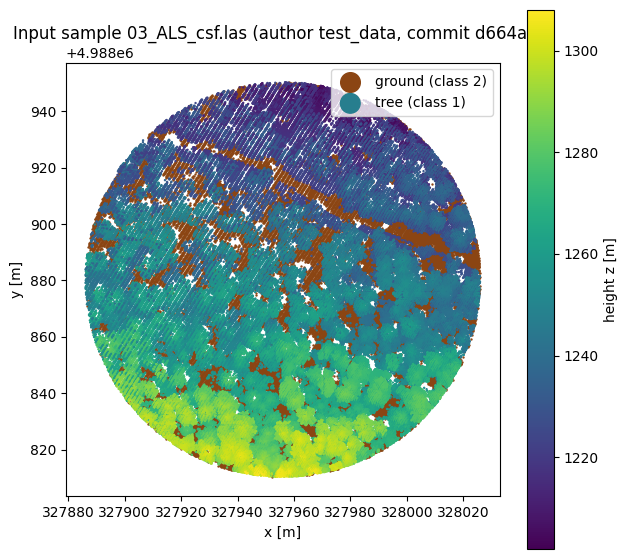

In [ ]:
import laspy, numpy as np
import matplotlib.pyplot as plt
las = laspy.read('/content/its_data/03_ALS_csf.las')
X = np.asarray(las.x); Y = np.asarray(las.y); Z = np.asarray(las.z); CLS = np.asarray(las.classification)
print('points:', len(X), '| class counts:', dict(zip(*np.unique(CLS, return_counts=True))))
print('x [m]: %.1f .. %.1f | y [m]: %.1f .. %.1f | z [m]: %.1f .. %.1f' % (X.min(), X.max(), Y.min(), Y.max(), Z.min(), Z.max()))
area = (X.max()-X.min()) * (Y.max()-Y.min()); print('footprint: %.0f m x %.0f m, ~%.0f pts/m2' % (X.max()-X.min(), Y.max()-Y.min(), len(X)/area))
fig, ax = plt.subplots(figsize=(7, 7))
sel = CLS == 1
ax.scatter(X[~sel], Y[~sel], s=0.5, c='saddlebrown', label='ground (class 2)')
s = ax.scatter(X[sel], Y[sel], s=0.5, c=Z[sel], cmap='viridis', label='tree (class 1)')
fig.colorbar(s, ax=ax, label='height z [m]')
ax.set_title('Input sample 03_ALS_csf.las (author test_data, commit d664a2c)')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.legend(loc='upper right', markerscale=20)
ax.set_aspect('equal'); plt.savefig('/content/its_work_input.png', dpi=110, bbox_inches='tight'); plt.show()

## 4. Stage 1 — pit-free CHM + watershed initial segmentation (R / lidR)

Run the author's `R/individual_tree_seg_ws_li2012_batch.R` logic on the sample: DTM `tin()` 0.2 m → height normalization → pit-free CHM 0.2 m → treetops `lmf(4,2)` → watershed segmentation → ground points get treeID 0. **Documented lidR-4.x adaptations:** `lasnormalize` → `normalize_height`, `tree_detection` → `locate_trees`, `lastrees(las, watershed(chm))` → `segment_trees(las, watershed(chm))` (renames only, identical parameters); the DTM/CHM GeoTIFF side-outputs of the author script (unused by the pipeline) are not written. Expected: segmented point count and initial tree count printed.

**JP:** 著者の R スクリプトを lidR 4.x の関数名に合わせて実行します (パラメータは原著どおり)。分割点数と初期木数を出力します。

In [ ]:
import subprocess, time
r = "\n".join([
    'suppressMessages(library(lidR))',
    't0 <- Sys.time()',
    "las <- readLAS('/content/its_data/03_ALS_csf.las'); cat('points:', nrow(las@data), '\\n')",
    "dtm <- grid_terrain(las, res = 0.2, algorithm = tin())",
    "las <- normalize_height(las, tin())",
    "chm <- grid_canopy(las, res = 0.2, pitfree())",
    "ttops <- locate_trees(chm, lmf(4, 2))",
    "las_ws <- segment_trees(las, watershed(chm))",
    'trees_ws <- filter_poi(las_ws, !is.na(treeID))',
    'trees_ws@data$treeID[trees_ws@data$Classification == 2] = 0',
    "writeLAS(trees_ws, '/content/its_data/03_ALS_seg_ws.las')",
    "cat('WS trees:', max(trees_ws@data$treeID), ' ws points:', nrow(trees_ws@data), ' stage1 s:', round(Sys.time()-t0,1), '\\n')",
])
open('/content/its_code/stage1_ws.R', 'w').write(r + '\n')
t1 = time.time()
p = subprocess.Popen(['Rscript', '/content/its_code/stage1_ws.R'], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in p.stdout: print(line, end='', flush=True)
if p.wait(timeout=3600) != 0: raise RuntimeError('R stage 1 failed')
print(f'stage1 elapsed: {time.time()-t1:.1f} s')

points: 157665 


Warning messages:


1: There were 2 degenerated ground points. Some X Y Z coordinates were repeated. They were removed. 


2: There were 10 degenerated ground points. Some X Y coordinates were repeated but with different Z coordinates. min Z were retained. 


Registered S3 method overwritten by 'stars':


  method                  from


  st_interpolate_aw.stars sf  


WS trees: 755  ws points: 140923  stage1 s: 12.5 


stage1 elapsed: 20.4 s


## 5. Watershed result preview

Load the WS-segmented LAS written by R and display it colored by watershed tree label (ground in brown). This is the input to stages 2–3 and the baseline the optimized CCE refines.

**JP:** Watershed 初期分割 (ラベル別着色) を表示します。段階 2・3 の入力になります。

WS las extra dims: ['treeID']


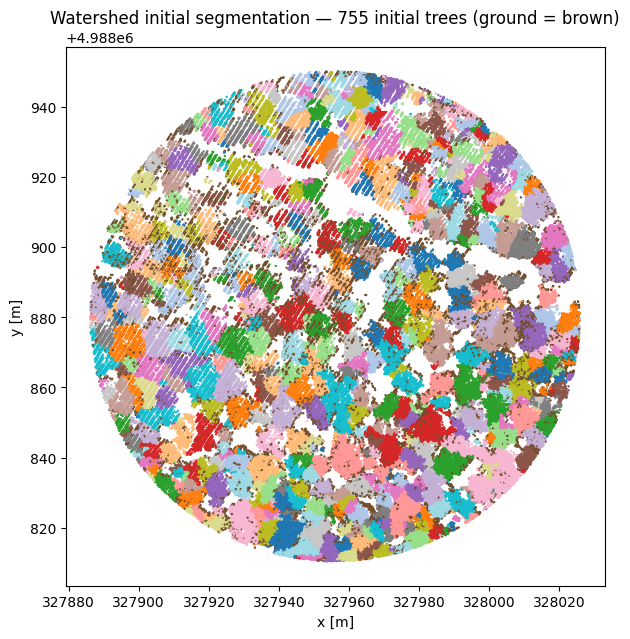

In [ ]:
ws = laspy.read('/content/its_data/03_ALS_seg_ws.las')
Xw = np.asarray(ws.x); Yw = np.asarray(ws.y); Zw = np.asarray(ws.z)
extra = list(ws.point_format.extra_dimension_names)
print('WS las extra dims:', extra)
treeid = np.asarray(ws['treeID']) if 'treeID' in extra else None
assert treeid is not None, 'treeID extra byte missing from lidR output'
fig, ax = plt.subplots(figsize=(7, 7))
rng = np.random.default_rng(0)
cmap = plt.cm.tab20(np.arange(int(treeid.max()) + 2) % 20); cmap[0] = [0.45, 0.31, 0.18, 1]
order = np.argsort(rng.random(len(treeid)))
ax.scatter(Xw[order], Yw[order], s=0.5, c=cmap[treeid[order].astype(int)])
ax.set_title(f'Watershed initial segmentation — {int(treeid.max())} initial trees (ground = brown)')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_aspect('equal')
plt.savefig('/content/its_work_ws.png', dpi=110, bbox_inches='tight'); plt.show()

## 6. Stage 2 — mean-shift bandwidth (author's `getbandwidth.py`)

Reproduce the author's bandwidth estimation: stack X/Y/Z of the watershed-segmented cloud, scale z by `zd = 6 = 1/Vr`, and call `sklearn.cluster.estimate_bandwidth` with `quantile = round(nP/((x1-x0)(y1-y0)))/nP` (the local point density). **Documented adaptation:** laspy 0.x `laspy.file.File` → laspy 2.x `laspy.read` (identical `x/y/z` accessors). Expected: one bandwidth value in the z-scaled units.

**JP:** 著者の bandwidth 推定式 (z を 6 で除算し密度を quantile に使用) を laspy 2.x で再現します。

In [ ]:
from sklearn.cluster import estimate_bandwidth
import time
P = np.vstack((Xw, Yw, Zw)).transpose()
zd = 6; P = P / np.array([1, 1, zd])          # author: zd = 6
nP = np.shape(P)[0]
x0 = P[np.lexsort([P[:, 0]])[0], 0]; x1 = P[np.lexsort([-P[:, 0]])[0], 0]
y0 = P[np.lexsort([P[:, 1]])[0], 1]; y1 = P[np.lexsort([-P[:, 1]])[0], 1]
den0 = round(nP / ((x1 - x0) * (y1 - y0)))    # author: point density
t1 = time.time()
bandwidth = float(estimate_bandwidth(P, quantile=den0 / nP))
print(f'nP={nP}  density={den0} pts/m2  bandwidth={bandwidth:.4f}  ({time.time()-t1:.1f} s)')

nP=140923  density=7 pts/m2  bandwidth=0.6340  (0.9 s)


## 7. Stage 3 — optimized CCE fine segmentation (author MATLAB core in Octave)

Patch the single display line of `cce_seg.m` (MATLAB `string` class does not exist in Octave; display only — the original file's SHA-256 is verified first), export the WS cloud and bandwidth to a `.mat` hand-off, and run an Octave driver that reproduces `its_ws_icce_batch.m` lines 28–60 verbatim: `get_treelabel_new` → `get_tree_metric_color` (WS metrics) → `cce_seg` with **Vr = 1/6** (z/6) and **sigSq2 = 10**. The core files execute as authored. An Octave `rand` seed is set because `MeanShiftCluster` is stochastic and the authors set none. Expected: per-segment optimization progress lines and final label count.

**JP:** MATLAB コアを Octave で原著のまま実行します (表示1行のみ修正、元ファイルは SHA-256 で検証)。Vr=1/6、sigSq2=10 は論文・コードの既定値です。

In [ ]:
import hashlib
from scipy.io import savemat
p = '/content/its_code/cce_seg.m'
src = open(p, 'rb').read()
assert hashlib.sha256(src).hexdigest() == 'd3119fced38a010433ef55689744ee017ea08866bc8e8dee4ec73df0851b9033', 'cce_seg.m changed upstream!'
old = "disp('已优化'+string(i)+'/'+string(treenum));".encode()
assert old in src
open(p, 'wb').write(src.replace(old, "disp(sprintf('optimized %d/%d', i, treenum));".encode()))
print('cce_seg.m: original SHA-256 verified, display line patched for Octave')
savemat('/content/its_work_stage2.mat', {'x': Xw.astype(np.float64), 'y': Yw.astype(np.float64),
                                          'z': Zw.astype(np.float64), 'treeid': treeid.astype(np.int32),
                                          'bandwidth': bandwidth})

cce_seg.m: original SHA-256 verified, display line patched for Octave


### Octave driver (batch lines 28–60, minus `table`/`LASread`/`LASwrite`)

**JP:** バッチスクリプトの数値部分をそのまま実行する Octave ドライバーです。

In [ ]:
import subprocess, time
oct_script = "\n".join([
    "addpath('/content/its_code');",
    "S = load('/content/its_work_stage2.mat');",
    "treelabel = get_treelabel_new(int32(S.treeid(:)));           % batch line 29",
    "treenum = max(S.treeid(:));                                   % batch line 30 (pre-renumber max)",
    "segtree = [S.x(:), S.y(:), S.z(:), double(treelabel)];        % batch line 31",
    "[tree_Metrics_ws, ~] = get_tree_metric_color(treelabel, treenum, segtree);  % batch line 33",
    "rand('seed', 42);                                             % reproducibility (MeanShift is stochastic)",
    "segtree_factor = segtree;",
    "segtree_factor(:,3) = segtree_factor(:,3)./6;                 % batch line 46: Vr = 1/6",
    "sigSq2 = 10;                                                  % batch line 47: Gaussian kernel",
    "treelabel2 = cce_seg(treenum, treenum-1, segtree_factor, S.bandwidth, treelabel, sigSq2);  % batch line 48",
    "treenum2 = max(treelabel2);                                   % batch line 50",
    "segtree2 = [S.x(:), S.y(:), S.z(:), double(treelabel2)];      % batch line 51",
    "[tree_Metrics, rgb_color] = get_tree_metric_color(treelabel2, treenum2, segtree2);  % batch line 52",
    "save('-v7', '/content/its_work_stage3.mat', 'treelabel2', 'tree_Metrics_ws', 'tree_Metrics', 'rgb_color', 'treenum', 'treenum2');",
    "printf('done: %d -> %d labels\\n', treenum, treenum2);",
])
open('/content/its_code/stage3_driver.m', 'w').write(oct_script + '\n')
t1 = time.time()
p = subprocess.Popen(['octave', '--no-gui', '--quiet', '/content/its_code/stage3_driver.m'], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in p.stdout: print(line, end='', flush=True)
if p.wait(timeout=7200) != 0: raise RuntimeError('Octave stage 3 failed')
print(f'stage3 elapsed: {time.time()-t1:.1f} s')

    cce_seg at line 22 column 37


    /content/its_code/stage3_driver.m at line 11 column 12


    cce_seg at line 22 column 37


    /content/its_code/stage3_driver.m at line 11 column 12


cn = 23


...

    /content/its_code/stage3_driver.m at line 11 column 12


    cce_seg at line 61 column 115


    /content/its_code/stage3_driver.m at line 11 column 12


done: 755 -> 774 labels


stage3 elapsed: 161.0 s


## 8. Tree metrics — watershed vs watershed+optimized CCE

Collect the author's `tree_Metrics` (FID, treetop Position_X/Y, Crown, Height) for both stages, show a summary table and the first rows, and save both CSVs. Expected: the optimized CCE stage splits merged crowns, so the tree count changes versus watershed-only.

**JP:** WS と WS+CCE の樹木計量表 (樹頂位置・樹冠幅・樹高) を表示し CSV 保存します。CCE により分裂・統合が起き木数が変化します。

In [ ]:
from scipy.io import loadmat
import pandas as pd
res = loadmat('/content/its_work_stage3.mat')
tl2 = res['treelabel2'].ravel().astype(int); tm_ws = res['tree_Metrics_ws']; tm = res['tree_Metrics']
n_ws = int(res['treenum'].ravel()[0]); n_fin = int(res['treenum2'].ravel()[0])
print(f'trees: watershed={n_ws}  ->  watershed+optimized CCE={n_fin}')
cols = ['FID', 'Position_X', 'Position_Y', 'Crown', 'Height', 'Crown_X', 'Crown_Y']
def to_df(m):
    df = pd.DataFrame(m, columns=cols)
    return df[df.FID > 0]  # drop zero padding rows (label 0 = ground)
df_ws, df_fin = to_df(tm_ws), to_df(tm)
print('--- watershed metrics (first rows, metres) ---'); print(df_ws.head())
print('--- watershed + optimized CCE metrics (first rows, metres) ---'); print(df_fin.head())
df_fin.to_csv('/content/its_tree_metrics_ws_icce.csv', index=False); df_ws.to_csv('/content/its_tree_metrics_ws.csv', index=False)
summary = pd.DataFrame({'trees': [n_ws, n_fin],
                        'median height [m]': [df_ws.Height.median(), df_fin.Height.median()],
                        'median crown [m]': [df_ws.Crown.median(), df_fin.Crown.median()]},
                       index=['watershed', 'watershed + optimized CCE'])
print(summary)

trees: watershed=755  ->  watershed+optimized CCE=774
--- watershed metrics (first rows, metres) ---
   FID  Position_X  Position_Y  Crown  Height  Crown_X  Crown_Y
0  1.0   327961.69  4988823.86  7.805   31.16     8.32     7.29
1  2.0   327956.03  4988826.03  3.825   30.53     3.14     4.51
2  3.0   327934.35  4988836.24  9.035   30.25    10.74     7.33
3  4.0   328017.28  4988848.77  7.375   30.24     7.35     7.40
4  5.0   327936.09  4988831.50  8.350   30.08     7.26     9.44
--- watershed + optimized CCE metrics (first rows, metres) ---
   FID  Position_X  Position_Y  Crown  Height  Crown_X  Crown_Y
0  1.0   327961.69  4988823.86  7.805   31.16     8.32     7.29
1  2.0   327956.03  4988826.03  3.825   30.53     3.14     4.51
2  3.0   327934.35  4988836.24  9.035   30.25    10.74     7.33
3  4.0   328017.28  4988848.77  7.375   30.24     7.35     7.40
4  5.0   327936.09  4988831.50  8.350   30.08     7.26     9.44
                           trees  median height [m]  median crown [m

## 9. Final comparison — input vs watershed vs watershed + optimized CCE

Render three panels from the actual data: input heights, WS labels, final WS+optimized-CCE labels. This saved figure is the notebook's representative output (labels are method outputs; no reference annotation exists for this sample).

**JP:** 入力・WS・WS+最適化CCE の 3 パネル比較図を保存・表示します。

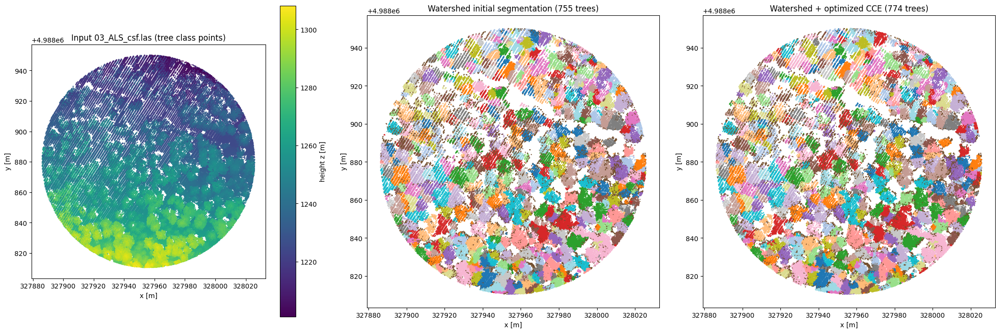

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax in axes: ax.set_aspect('equal'); ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
s0 = axes[0].scatter(X, Y, s=0.4, c=Z, cmap='viridis')
fig.colorbar(s0, ax=axes[0], label='height z [m]'); axes[0].set_title('Input 03_ALS_csf.las (tree class points)')
cmap2 = plt.cm.tab20(np.arange(n_ws + 2) % 20); cmap2[0] = [0.45, 0.31, 0.18, 1]
order = np.argsort(np.random.default_rng(0).random(len(treeid)))
axes[1].scatter(Xw[order], Yw[order], s=0.4, c=cmap2[treeid[order].astype(int)]); axes[1].set_title(f'Watershed initial segmentation ({n_ws} trees)')
cmap3 = plt.cm.tab20(np.arange(n_fin + 2) % 20); cmap3[0] = [0.45, 0.31, 0.18, 1]
order3 = np.argsort(np.random.default_rng(1).random(len(tl2)))
axes[2].scatter(Xw[order3], Yw[order3], s=0.4, c=cmap3[tl2[order3]]); axes[2].set_title(f'Watershed + optimized CCE ({n_fin} trees)')
plt.tight_layout(); plt.savefig('/content/its_ws_vs_icce.png', dpi=110, bbox_inches='tight'); plt.show()

## 10. Labeled outputs — LAS point cloud and metric CSVs

Write the final labeled point cloud (author batch lines 56–60: final `treeID` plus per-tree pseudo-color from `get_tree_metric_color`'s colormap) as a LAS 1.2 point-format-2 file, alongside the two metric CSVs. Expected: file sizes and a roundtrip label-count check printed.

**JP:** 最終ラベルを treeID + RGB 付き LAS として書き出し、計量 CSV と併せて保存・検証します。

In [ ]:
import laspy, numpy as np, os
header = laspy.LasHeader(point_format=2, version='1.2')
out = laspy.LasData(header)
out.x, out.y, out.z = Xw, Yw, Zw
rgb = np.asarray(res['rgb_color'])
out.red = rgb[:, 0].astype(np.uint16); out.green = rgb[:, 1].astype(np.uint16); out.blue = rgb[:, 2].astype(np.uint16)
out.add_extra_dim(laspy.ExtraBytesParams(name='treeID', type=np.int32))
out['treeID'] = tl2.astype(np.int32)
out.write('/content/its_data/03_ALS_seg_ws_icce.las')
for f in ['/content/its_data/03_ALS_seg_ws_icce.las', '/content/its_tree_metrics_ws_icce.csv', '/content/its_tree_metrics_ws.csv']:
    print(f, os.path.getsize(f), 'bytes')
chk = laspy.read('/content/its_data/03_ALS_seg_ws_icce.las')
print('roundtrip: points', len(chk.points), '| distinct labels:', int(np.unique(np.asarray(chk['treeID'])).max()) + 1)

/content/its_data/03_ALS_seg_ws_icce.las 4228163 bytes
/content/its_tree_metrics_ws_icce.csv 67011 bytes
/content/its_tree_metrics_ws.csv 65414 bytes
roundtrip: points 140923 | distinct labels: 775


## Interpretation, differences from the paper, validation record

- **What ran:** the paper's complete three-stage ITS pipeline (pit-free CHM + watershed → bandwidth estimation → optimized CCE) on the author's embedded ALS sample, with the author's numerical core executed unmodified (Octave for the MATLAB stage, lidR for the R stage).
- **Single-example scope:** one 140 m × 140 m ALS plot. The paper's accuracy tables (P1–P5 Saihanba ULS and 14 NEWFOR Alpine plots, e.g. average matching rate 0.78, F 0.70) are **not** reproduced here — no reference tree positions are published for this sample, so no detection-rate/F-score or height RMSE can be computed. This demo verifies runnability and plausibility, not published accuracy.
- **Documented changes:** lidR 4.x API renames (`normalize_height`, `locate_trees`, `segment_trees`); laspy 2.x instead of 0.x; MATLAB `string` display line; `table`/`LASread`/`LASwrite` replaced by laspy I/O; DTM/CHM GeoTIFF side-outputs omitted; Octave `rand` seed 42. The core algorithms are untouched.
- **Environment:** this run was executed on a free Colab **CPU** runtime; per-stage wall times are in the outputs above. The paper reports ≤ 6 min for a much denser 50 × 50 m plot on an i7-8700.
- **Provenance:** code `liyi-rs/ITS_WS_ICCE` @ `d664a2ca15649aa1e628ea42da8b2c89b44253cf` (2022-09-11, no LICENSE file); sample `test_data/03_ALS_csf.las`, blob SHA-1 `28f9a008…`; paper DOI 10.1002/ece3.10297 (PMC10338759).
- **PhenoPaper investigation note:** the PhenoPaper investigation run `p-6e86a87cb81f3e95d027928e41018947-20261008T110854Z-1009096` (status completed, flow `complete_from_fulltext`, reviewStatus `unverified`) was used as research guidance; all parameters above were re-verified directly against the pinned code.

**JP:** 本実行は 1 サンプル (140 m 四方) の動作確認です。論文の精度表 (照合率 0.78 など) は参照データが無いため検証対象外。変更点は上記の通り最小限で、アルゴリズム本体は原著のままです。